In [8]:
import requests
import pandas as pd

In [13]:
servicekey = "cNx+1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO/U+UhQqKv2E4WScQrT/mI1hrZR4ayBRqtIaKHC3BywjHiX3w=="
url = "http://apis.data.go.kr/B553077/api/open/sdsc2/storeListInUpjong"
payload = dict(servicekey = servicekey, divId = "indsSclsCd", key = "I21006", numOfRows = 10, pageNo = 1, type = "json")
r = requests.get(url, params=payload)
data = r.json()
print(r.url)
print(r.status_code)
response = r.json()

http://apis.data.go.kr/B553077/api/open/sdsc2/storeListInUpjong?servicekey=cNx%2B1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO%2FU%2BUhQqKv2E4WScQrT%2FmI1hrZR4ayBRqtIaKHC3BywjHiX3w%3D%3D&divId=indsSclsCd&key=I21006&numOfRows=10&pageNo=1&type=json
200


In [29]:
result = {}
for item in response['body']['items']:
    for key, value in zip(response['header']['columns'], item.values()):
        result.setdefault(key, []).append(value)

In [ ]:
df = pd.DataFrame(result)
df

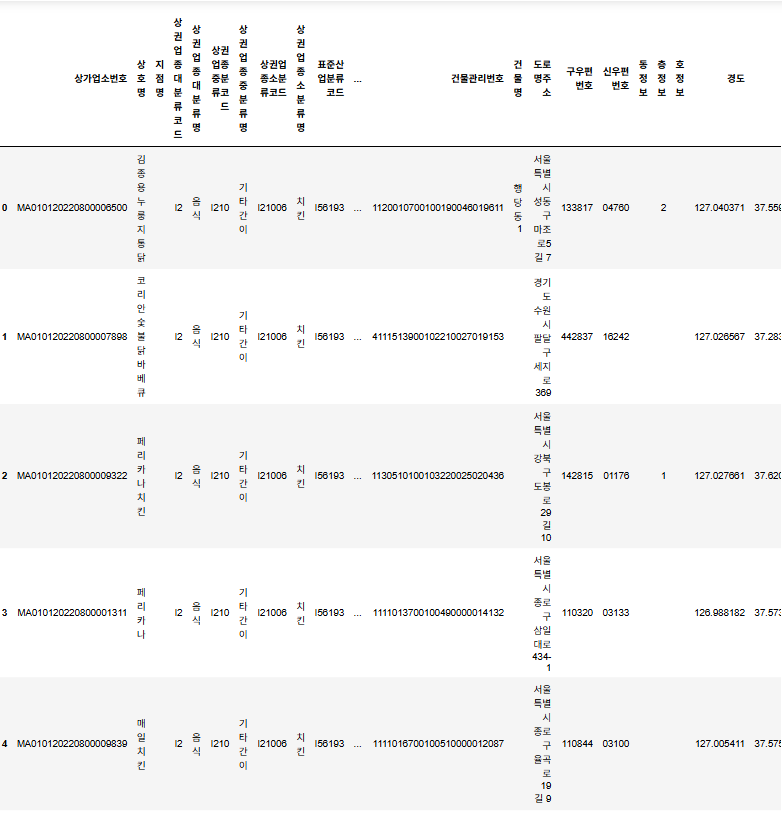

In [27]:
response.keys()

dict_keys(['header', 'body'])

In [28]:
response['header']['columns']

['상가업소번호',
 '상호명',
 '지점명',
 '상권업종대분류코드',
 '상권업종대분류명',
 '상권업종중분류코드',
 '상권업종중분류명',
 '상권업종소분류코드',
 '상권업종소분류명',
 '표준산업분류코드',
 '표준산업분류명',
 '시도코드',
 '시도명',
 '시군구코드',
 '시군구명',
 '행정동코드',
 '행정동명',
 '법정동코드',
 '법정동명',
 'PNU코드',
 '대지구분코드',
 '대지구분명',
 '지번본번지',
 '지번부번지',
 '지번주소',
 '도로명코드',
 '도로명',
 '건물본번지',
 '건물부번지',
 '건물관리번호',
 '건물명',
 '도로명주소',
 '구우편번호',
 '신우편번호',
 '동정보',
 '층정보',
 '호정보',
 '경도',
 '위도']

# 함수화

In [1]:
import requests
import pandas as pd
import time

In [2]:
def unpack_data(response):
    result = {}
    for item in response['body']['items']:
        for key, value in zip(response['header']['columns'], item.values()):
            result.setdefault(key, []).append(value)
    df = pd.DataFrame(result)       
    return df

In [3]:
page = 1
result_dfs = []
while True:
    url = "http://apis.data.go.kr/B553077/api/open/sdsc2/storeListInUpjong"
    servicekey = "cNx+1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO/U+UhQqKv2E4WScQrT/mI1hrZR4ayBRqtIaKHC3BywjHiX3w=="
    payload = dict(servicekey = servicekey, divId = "indsSclsCd", key = "I21006", numOfRows = 1000, pageNo = page, type = "json")
    r = requests.get(url, params=payload)
    data = r.json()
    print(r.url, end="\r")
    print("\n")
    print(r.status_code, end="\r")
    print("\n")
    
    response = r.json()
    total_page = (response['body']['totalCount'] // 1000) + 1
    result_dfs.append(unpack_data(response))
    print(f"{page}/{total_page} 수집중", end="\r")

    if page < total_page:
        page += 1
    else:
        break
    time.sleep(0.3)
    
result = pd.concat(result_dfs)    
#drop=True 다시 공부하자 (개념 미숙)
result = result.reset_index(drop=True)
result.to_csv("공공데이터_상권정보_202504.csv", encoding = "utf-8", index=False)

http://apis.data.go.kr/B553077/api/open/sdsc2/storeListInUpjong?servicekey=cNx%2B1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO%2FU%2BUhQqKv2E4WScQrT%2FmI1hrZR4ayBRqtIaKHC3BywjHiX3w%3D%3D&divId=indsSclsCd&key=I21006&numOfRows=1000&pageNo=1&type=json

200

http://apis.data.go.kr/B553077/api/open/sdsc2/storeListInUpjong?servicekey=cNx%2B1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO%2FU%2BUhQqKv2E4WScQrT%2FmI1hrZR4ayBRqtIaKHC3BywjHiX3w%3D%3D&divId=indsSclsCd&key=I21006&numOfRows=1000&pageNo=2&type=json

200

http://apis.data.go.kr/B553077/api/open/sdsc2/storeListInUpjong?servicekey=cNx%2B1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO%2FU%2BUhQqKv2E4WScQrT%2FmI1hrZR4ayBRqtIaKHC3BywjHiX3w%3D%3D&divId=indsSclsCd&key=I21006&numOfRows=1000&pageNo=3&type=json

200

http://apis.data.go.kr/B553077/api/open/sdsc2/storeListInUpjong?servicekey=cNx%2B1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO%2FU%2BUhQqKv2E4WScQrT%2FmI1hrZR4ayBRqtIaKHC3BywjHiX3w%3D%3D&divId=indsSclsCd&key=I21006&numOfRows=1000&pageNo=4&type=json

200

http://apis.data.go.kr/B

http://apis.data.go.kr/B553077/api/open/sdsc2/storeListInUpjong?servicekey=cNx%2B1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO%2FU%2BUhQqKv2E4WScQrT%2FmI1hrZR4ayBRqtIaKHC3BywjHiX3w%3D%3D&divId=indsSclsCd&key=I21006&numOfRows=1000&pageNo=35&type=json

200

http://apis.data.go.kr/B553077/api/open/sdsc2/storeListInUpjong?servicekey=cNx%2B1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO%2FU%2BUhQqKv2E4WScQrT%2FmI1hrZR4ayBRqtIaKHC3BywjHiX3w%3D%3D&divId=indsSclsCd&key=I21006&numOfRows=1000&pageNo=36&type=json

200

http://apis.data.go.kr/B553077/api/open/sdsc2/storeListInUpjong?servicekey=cNx%2B1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO%2FU%2BUhQqKv2E4WScQrT%2FmI1hrZR4ayBRqtIaKHC3BywjHiX3w%3D%3D&divId=indsSclsCd&key=I21006&numOfRows=1000&pageNo=37&type=json

200

http://apis.data.go.kr/B553077/api/open/sdsc2/storeListInUpjong?servicekey=cNx%2B1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO%2FU%2BUhQqKv2E4WScQrT%2FmI1hrZR4ayBRqtIaKHC3BywjHiX3w%3D%3D&divId=indsSclsCd&key=I21006&numOfRows=1000&pageNo=38&type=json

200

http://apis.data.go.

In [35]:
total_page = (response['body']['totalCount'] // 1000) + 1
total_page

43

# 전체 소분류 모두 추출하기 (소분류 code + 반복문)

In [5]:
!pip install openpyxl

#### header
* 몇 번째 행을 '컬럼명'으로 쓸 것인지 정하는 키워드

In [5]:
import os
import pandas as pd

In [11]:
ori_data = pd.read_excel("./data/소상공인시장진흥공단_상가(상권)정보_업종분류(2302)_및_연계표_v1.0.xlsx", engine='openpyxl', header=[1])
ori_data

,대분류코드,대분류명,중분류코드,중분류명,소분류코드,소분류명
0,G2,소매업,G202,자동차 부품 및 내장품 소매업,G20201,타이어 소매업
1,G2,소매업,G202,자동차 부품 및 내장품 소매업,G20202,자동차 부품 소매업
2,G2,소매업,G203,모터사이클 및 부품 소매업,G20301,모터사이클 및 부품 소매업
3,G2,소매업,G204,종합 소매업,G20404,슈퍼마켓
4,G2,소매업,G204,종합 소매업,G20405,편의점
...,...,...,...,...,...,...
242,S2,수리 및 개인 서비스업,S209,세탁업,S20902,셀프 빨래방
243,S2,수리 및 개인 서비스업,S210,장례식장 및 관련 서비스업,S21001,장례식장
244,S2,수리 및 개인 서비스업,S210,장례식장 및 관련 서비스업,S21002,화장터/묘지/납골당
245,S2,수리 및 개인 서비스업,S211,기타 개인서비스,S21101,예식장업


In [10]:
ori_data['소분류코드']

0      G20201
1      G20202
2      G20301
3      G20404
4      G20405
        ...  
242    S20902
243    S21001
244    S21002
245    S21101
246    S21105
Name: 소분류코드, Length: 247, dtype: object

## 모든 소상공인 소분류업종이 추출된다.

# 소분류코드와 소분류명 묶어 csv 파일로 저장하기

In [ ]:
for code, name in zip(ori_data['소분류코드'], ori_data['소분류명']):
    name = name.replace("/", "_")
    page = 1
    result_dfs = []
    while True:
        url = "http://apis.data.go.kr/B553077/api/open/sdsc2/storeListInUpjong"
        servicekey = "cNx+1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO/U+UhQqKv2E4WScQrT/mI1hrZR4ayBRqtIaKHC3BywjHiX3w=="
        payload = dict(servicekey = servicekey, divId = "indsSclsCd", key = code, numOfRows = 1000, pageNo = page, type = "json")
        r = requests.get(url, params=payload)
        data = r.json()
        print(r.url, end="\r")
        print(r.status_code, end="\r")
        response = r.json()
        total_page = (response['body']['totalCount'] // 1000) + 1
        result_dfs.append(unpack_data(response))
        print(f"{page}/{total_page} 수집중", end="\r")

        if page < total_page:
            page += 1
        else:
            break
        time.sleep(0.3)

    result = pd.concat(result_dfs)    
    result = result.reset_index(drop=True)
    result.to_csv(f"공공데이터_{name}_상권정보_202504.csv", encoding = "utf-8", index=False)